# Bitcoin Price Prediction

## System Setup

In [1]:
import sys

print(sys.executable)
print(sys.version)

/opt/anaconda3/envs/bitcoin_tf/bin/python
3.12.13 | packaged by Anaconda, Inc. | (main, Jul  9 2026, 14:29:01) [Clang 20.1.8 ]


In [2]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)

TensorFlow: 2.16.1


In [3]:
# %pip install --upgrade --force-reinstall "numpy<2.0" "scipy<1.14" "scikit-learn"

In [4]:
# %pip install xgboost

In [5]:
# %pip install pandas numpy matplotlib plotly scikit-learn

## Import Libraries and Data

In [6]:
# Library imports

import os
import pandas as pd
import numpy as np
import math
import datetime as dt
import matplotlib.pyplot as plt
from plotly.subplots import make_subplots

In [7]:
import plotly.io as pio
pio.renderers.default = "iframe"
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [8]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import xgboost as xgb

from tensorflow.keras.models import Sequential

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.16.1
GPU: []


In [9]:
# %pip install tensorflow

In [10]:
# For Evalution we will use these library

from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, explained_variance_score, r2_score
from sklearn.preprocessing import MinMaxScaler

# For model building we will use these library
import xgboost as xgb

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, LSTM, Input, GRU
from tensorflow.keras.optimizers import Adam

# For PLotting we will use these library

import matplotlib.pyplot as plt
from itertools import cycle
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

In [11]:
# !pip install optuna

In [12]:
# %pip install seaborn

In [13]:
# %pip install --upgrade plotly nbformat ipywidgets

In [14]:
import seaborn as sns
sns.set_theme(style="darkgrid")

In [15]:
import os
import random
import numpy as np
import tensorflow as tf

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

tf.config.experimental.enable_op_determinism()

In [16]:
maindf = pd.read_csv('dataset_upto_20august.csv')

In [17]:
print('Total number of days present in the dataset: ',maindf.shape[0])
print('Total number of fields present in the dataset: ',maindf.shape[1])
print('Shape of main data : ',maindf.shape)

Total number of days present in the dataset:  3154
Total number of fields present in the dataset:  12
Shape of main data :  (3154, 12)


In [18]:
maindf.head()

,Open time,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,Ignore
0,2018-01-01 00:00:00+00:00,13715.65,13818.55,12750.00,13380.00,8609.915844,2018-01-01 23:59:59.999000 UTC,1.147997e+08,105595,3961.938946,5.280975e+07,0
1,2018-01-02 00:00:00+00:00,13382.16,15473.49,12890.02,14675.11,20078.092111,2018-01-02 23:59:59.999000 UTC,2.797171e+08,177728,11346.326739,1.580801e+08,0
2,2018-01-03 00:00:00+00:00,14690.00,15307.56,14150.00,14919.51,15905.667639,2018-01-03 23:59:59.999000 UTC,2.361169e+08,162787,8994.953566,1.335873e+08,0
3,2018-01-04 00:00:00+00:00,14919.51,15280.00,13918.04,15059.54,21329.649574,2018-01-04 23:59:59.999000 UTC,3.127816e+08,170310,12680.812951,1.861168e+08,0
4,2018-01-05 00:00:00+00:00,15059.56,17176.24,14600.00,16960.39,23251.491125,2018-01-05 23:59:59.999000 UTC,3.693220e+08,192969,13346.622293,2.118299e+08,0


In [19]:
maindf.isnull().sum()

Open time                       0
Open                            0
High                            0
Low                             0
Close                           0
Volume                          0
Close time                      0
Quote asset volume              0
Number of trades                0
Taker buy base asset volume     0
Taker buy quote asset volume    0
Ignore                          0
dtype: int64

In [20]:
maindf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3154 entries, 0 to 3153
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Open time                     3154 non-null   object 
 1   Open                          3154 non-null   float64
 2   High                          3154 non-null   float64
 3   Low                           3154 non-null   float64
 4   Close                         3154 non-null   float64
 5   Volume                        3154 non-null   float64
 6   Close time                    3154 non-null   object 
 7   Quote asset volume            3154 non-null   float64
 8   Number of trades              3154 non-null   int64  
 9   Taker buy base asset volume   3154 non-null   float64
 10  Taker buy quote asset volume  3154 non-null   float64
 11  Ignore                        3154 non-null   int64  
dtypes: float64(8), int64(2), object(2)
memory usage: 295.8+ KB


In [21]:
maindf.columns

Index(['Open time', 'Open', 'High', 'Low', 'Close', 'Volume', 'Close time',
       'Quote asset volume', 'Number of trades', 'Taker buy base asset volume',
       'Taker buy quote asset volume', 'Ignore'],
      dtype='object')

In [22]:
maindf['Open time'] = pd.to_datetime(
    maindf['Open time'],
    format='mixed',
    utc=True
).dt.strftime('%Y-%m-%d')

maindf['Close time'] = pd.to_datetime(
    maindf['Close time'],
    format='mixed',
    utc=True
).dt.strftime('%Y-%m-%d')

print(maindf[['Open time', 'Close time']].head())

    Open time  Close time
0  2018-01-01  2018-01-01
1  2018-01-02  2018-01-02
2  2018-01-03  2018-01-03
3  2018-01-04  2018-01-04
4  2018-01-05  2018-01-05


In [23]:
# Open and close time is same and ignore has 0 values only
df = maindf.drop(columns=['Ignore','Close time'])

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3154 entries, 0 to 3153
Data columns (total 10 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Open time                     3154 non-null   object 
 1   Open                          3154 non-null   float64
 2   High                          3154 non-null   float64
 3   Low                           3154 non-null   float64
 4   Close                         3154 non-null   float64
 5   Volume                        3154 non-null   float64
 6   Quote asset volume            3154 non-null   float64
 7   Number of trades              3154 non-null   int64  
 8   Taker buy base asset volume   3154 non-null   float64
 9   Taker buy quote asset volume  3154 non-null   float64
dtypes: float64(8), int64(1), object(1)
memory usage: 246.5+ KB


In [25]:
df['Open time'] = pd.to_datetime(df['Open time'])

In [26]:
df['Open time'].dt.year

0       2018
1       2018
2       2018
3       2018
4       2018
        ... 
3149    2026
3150    2026
3151    2026
3152    2026
3153    2026
Name: Open time, Length: 3154, dtype: int32

In [27]:
## SEED CELL

## EDA

In [28]:
import plotly.graph_objects as go

In [29]:
import plotly.graph_objects as go
import plotly.io as pio

print("Plotly:", __import__("plotly").__version__)
print("Renderer:", pio.renderers.default)
print(pio.renderers)

Plotly: 6.9.0
Renderer: iframe
Renderers configuration
-----------------------
    Default renderer: 'iframe'
    Available renderers:
        ['plotly_mimetype', 'jupyterlab', 'nteract', 'vscode',
         'notebook', 'notebook_connected', 'kaggle', 'azure', 'colab',
         'cocalc', 'databricks', 'json', 'png', 'jpeg', 'jpg', 'svg',
         'pdf', 'browser', 'firefox', 'chrome', 'chromium', 'iframe',
         'iframe_connected', 'sphinx_gallery', 'sphinx_gallery_png']



In [30]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=["Close Price (Standard Scale)", "Close Price (Logarithmic Scale)"])

for col, log in [(1, False), (2, True)]:
    fig.add_trace(go.Scatter(x=df["Open time"], y=df["Close"], mode="lines",
                             name="Close Price"), row=1, col=col)

fig.update_layout(height=600, width=1200, title="Close Price Analysis", showlegend=True)
fig.update_yaxes(title="Close Price USD", row=1, col=1)
fig.update_yaxes(title="Close Price USD (Log Scale)", type="log", row=1, col=2)
fig.update_xaxes(title="Date")
fig.show()

In [31]:
pio.renderers.default = "notebook_connected"

In [32]:
import plotly.io as pio
pio.renderers.default = "iframe"

fig = go.Figure(go.Scatter(
    x=df['Open time'],
    y=df['Close'],
    mode='lines',
    name='Close Price'
))

fig.update_layout(
    title='Bitcoin Close Price',
    xaxis_title='Date',
    yaxis_title='Close Price (USD)'
)

fig.show()

In [33]:
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Open Price (Standard Scale)", "Open Price (Logarithmic Scale)")
)

for col, color in [(1, None), (2, "green")]:
    fig.add_trace(
        go.Scatter(x=df['Open time'], y=df['Open'], mode='lines',
                   name='Open Price', line=dict(color=color) if color else None),
        row=1, col=col
    )

fig.update_layout(
    height=600, width=1200,
    title="Open Price Analysis",
    showlegend=True
)

fig.update_yaxes(title="Open Price (USD)", row=1, col=1)
fig.update_yaxes(title="Open Price (USD - Log Scale)", type="log", row=1, col=2)
fig.update_xaxes(title="Date", row=1, col=1)
fig.update_xaxes(title="Date", row=1, col=2)

fig.show()

In [34]:
df['SMA_50'] = df['Close'].rolling(window=50).mean()
df['SMA_200'] = df['Close'].rolling(window=200).mean()

# Create Plotly subplots
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=('Close Price with SMAs (Standard Scale)', 'Close Price with SMAs (Logarithmic Scale)'))

# Standard Line Chart with SMAs
fig.add_trace(go.Scatter(x=df['Open time'], y=df['Close'], mode='lines', name='Close Price', line=dict(color='blue')),
              row=1, col=1)
fig.add_trace(go.Scatter(x=df['Open time'], y=df['SMA_50'], mode='lines', name='SMA 50', line=dict(color='red')),
              row=1, col=1)
fig.add_trace(go.Scatter(x=df['Open time'], y=df['SMA_200'], mode='lines', name='SMA 200', line=dict(color='green')),
              row=1, col=1)

# Logarithmic Scale Line Chart with SMAs
fig.add_trace(go.Scatter(x=df['Open time'], y=df['Close'], mode='lines', name='Close Price', line=dict(color='blue'), showlegend=False),
              row=1, col=2)
fig.add_trace(go.Scatter(x=df['Open time'], y=df['SMA_50'], mode='lines', name='SMA 50', line=dict(color='red'), showlegend=False),
              row=1, col=2)
fig.add_trace(go.Scatter(x=df['Open time'], y=df['SMA_200'], mode='lines', name='SMA 200', line=dict(color='green'), showlegend=False),
              row=1, col=2)


fig.update_layout(height=600, width=1200, title_text="Close Price Analysis with Simple Moving Averages",
                  xaxis_rangeslider_visible=False)

fig.update_yaxes(title_text="Close Price USD", row=1, col=1)
fig.update_yaxes(title_text="Close Price USD (Log Scale)", type="log", row=1, col=2)
fig.update_xaxes(title_text="Date", row=1, col=1)
fig.update_xaxes(title_text="Date", row=1, col=2)

fig.show()

In [35]:
df.columns

Index(['Open time', 'Open', 'High', 'Low', 'Close', 'Volume',
       'Quote asset volume', 'Number of trades', 'Taker buy base asset volume',
       'Taker buy quote asset volume', 'SMA_50', 'SMA_200'],
      dtype='object')

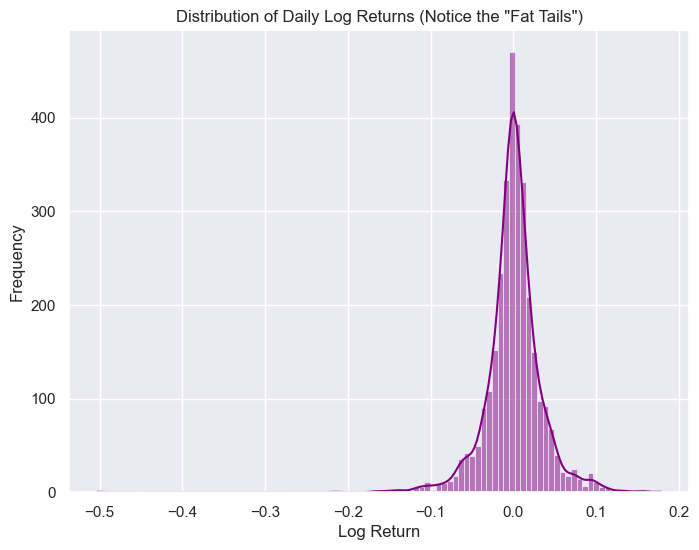

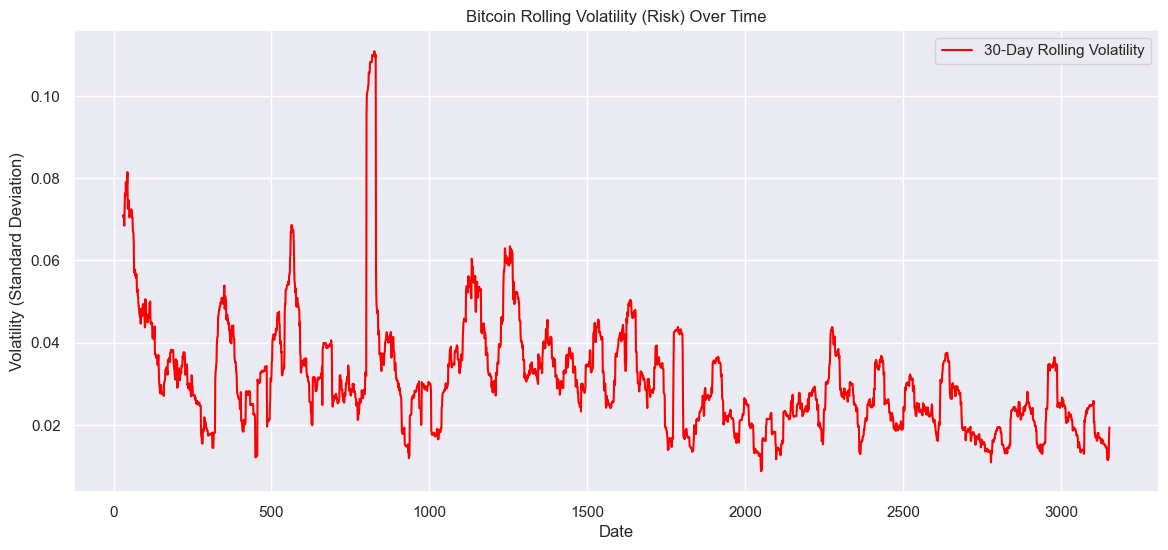

In [36]:
# Calculate Log Returns

df['Log Returns'] = np.log(df['Close'] / df['Close'].shift(1))

# --- Plot Distribution of Returns ---
plt.figure(figsize=(8, 6))
sns.histplot(df['Log Returns'].dropna(), bins=100, kde=True, color='purple')
plt.title('Distribution of Daily Log Returns (Notice the "Fat Tails")')
plt.xlabel('Log Return')
plt.ylabel('Frequency')
plt.show()

# Calculate & Plot 30-Day Rolling Volatility

df['Rolling Vol 30'] = df['Log Returns'].rolling(window=30).std()

plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Rolling Vol 30'], color='red', label='30-Day Rolling Volatility')
plt.title('Bitcoin Rolling Volatility (Risk) Over Time')
plt.xlabel('Date')
plt.ylabel('Volatility (Standard Deviation)')
plt.legend()
plt.show()

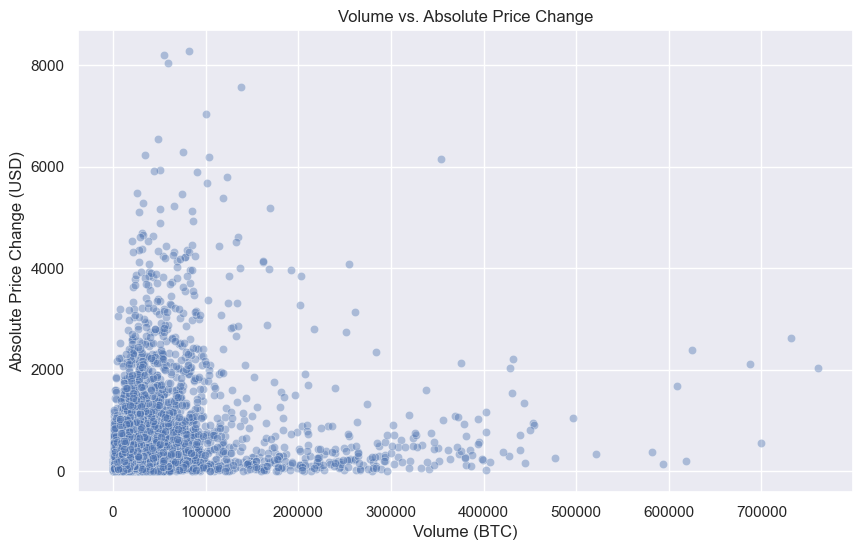

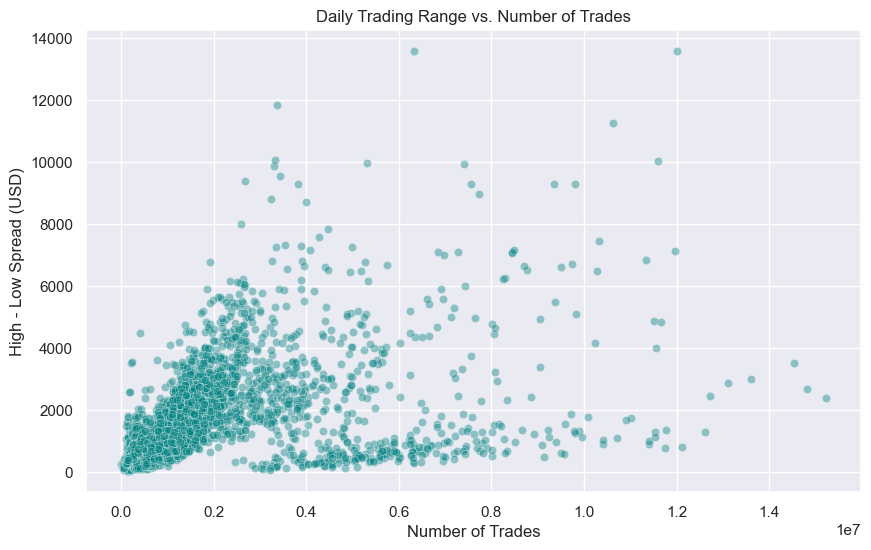

In [37]:
# Absolute price change for the period
df['Abs Price Change'] = abs(df['Close'] - df['Open'])

# The total spread from absolute top to bottom of the wick
df['High Low Spread'] = df['High'] - df['Low']

# Volume vs Absolute Price Change Correlation
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Volume', y='Abs Price Change', data=df, alpha=0.4)
plt.title('Volume vs. Absolute Price Change')
plt.xlabel('Volume (BTC)')
plt.ylabel('Absolute Price Change (USD)')
plt.show()

# High/Low spread vs no. of Trades
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Number of trades', y='High Low Spread', data=df, alpha=0.4, color='teal')
plt.title('Daily Trading Range vs. Number of Trades')
plt.xlabel('Number of Trades')
plt.ylabel('High - Low Spread (USD)')
plt.show()

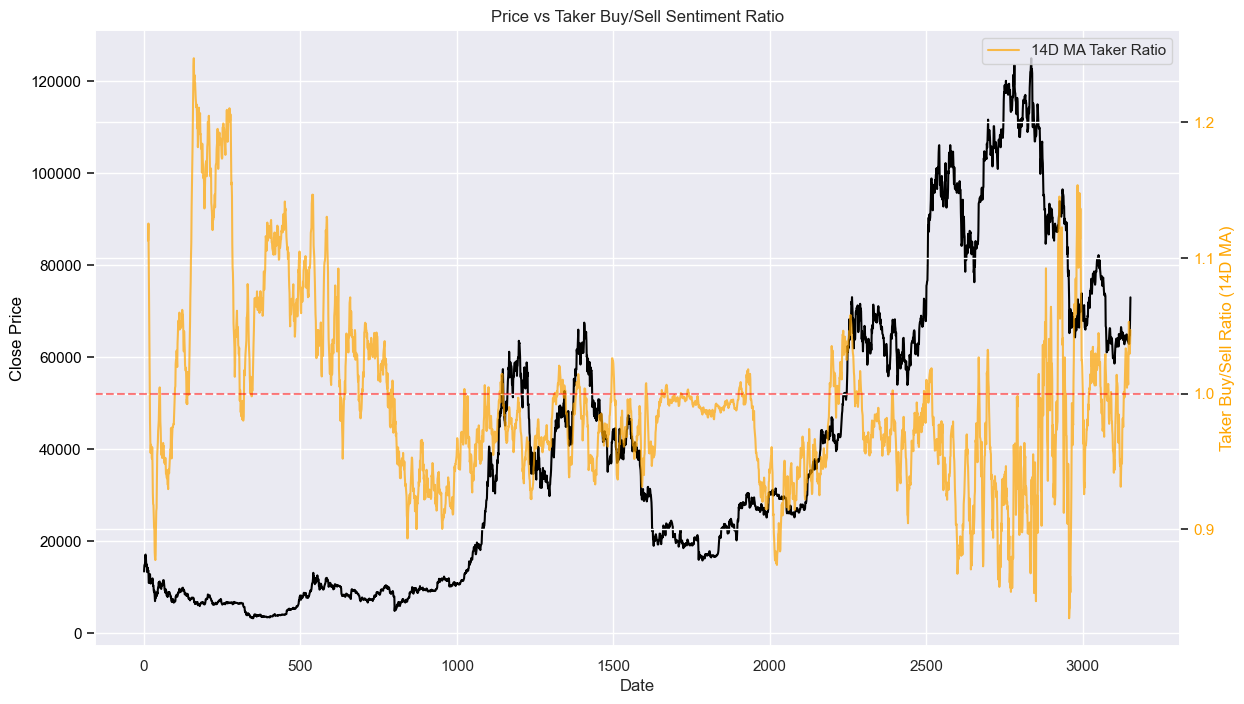

In [38]:
# Calculate Taker Sell Volume and Ratio

# Total Volume - Taker Buy Volume = Taker Sell Volume
df['Taker sell base asset volume'] = df['Volume'] - df['Taker buy base asset volume']

df['Taker Buy Sell Ratio'] = df['Taker buy base asset volume'] / (df['Taker sell base asset volume'] + 0.0001)

# Divergence Plot: Price vs Taker Ratio
fig, ax1 = plt.subplots(figsize=(14, 8))


ax1.plot(df.index, df['Close'], color='black', label='Close Price')
ax1.set_xlabel('Date')
ax1.set_ylabel('Close Price', color='black')
ax1.tick_params(axis='y', labelcolor='black')

ax2 = ax1.twinx()
# Applying a 14-day moving average to smooth the ratio for better visual divergence
ax2.plot(df.index, df['Taker Buy Sell Ratio'].rolling(window=14).mean(), color='orange', alpha=0.7, label='14D MA Taker Ratio')
ax2.set_ylabel('Taker Buy/Sell Ratio (14D MA)', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')
ax2.axhline(1.0, color='red', linestyle='--', alpha=0.5) # Baseline where Buy = Sell

plt.title('Price vs Taker Buy/Sell Sentiment Ratio')
plt.legend()
plt.show()

Detected 26 potential flash crash/liquidation events.


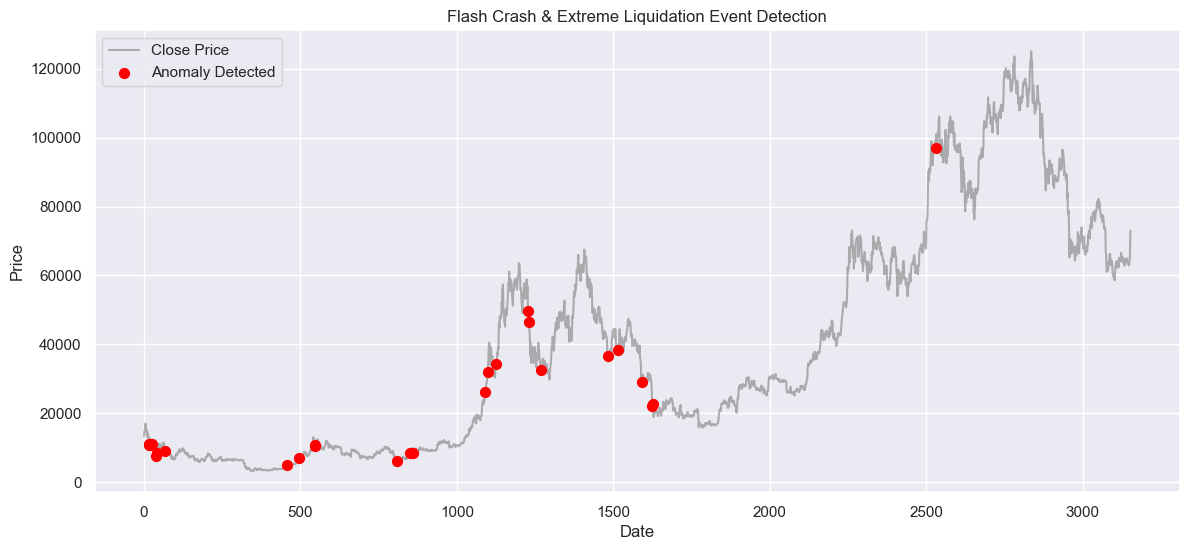

,Open,High,Low,Close,High Low Spread
16,10899.99,11680.99,9037.94,10988.79,2643.05
17,10972.59,11878.82,10435.33,10961.97,1443.49
22,10760.05,11399.00,9905.00,10799.18,1494.00
25,11184.70,11643.00,10311.15,11089.00,1331.85
37,7655.02,8476.00,7150.01,7599.00,1325.99
40,8683.93,9065.78,8120.00,8533.98,945.78
67,9267.07,9410.00,8329.00,9227.00,1081.00
457,4857.19,5275.01,4753.50,4932.60,521.51
496,7076.24,7521.78,6750.00,6967.31,771.78
546,10854.10,11282.28,10030.00,10624.93,1252.28


In [39]:
# Define Flash Crash Conditions
# Condition 1: Massive spread (e.g. High-Low spread is greater than 10% of the Open price)
massive_spread = df['High Low Spread'] > (df['Open'] * 0.10)

# Condition 2: Small real body (The difference between Open and Close is less than 20% of the total High-Low spread)
small_body = abs(df['Close'] - df['Open']) < (df['High Low Spread'] * 0.20)

# Filter dataframe for anomalies
flash_crashes = df[massive_spread & small_body]

print(f"Detected {len(flash_crashes)} potential flash crash/liquidation events.")

# Visualize Anomalies
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Close'], color='gray', label='Close Price', alpha=0.6)

# Overlay the anomalies as red dots
plt.scatter(flash_crashes.index, flash_crashes['Close'], color='red', s=50, label='Anomaly Detected', zorder=5)

plt.title('Flash Crash & Extreme Liquidation Event Detection')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

# Display the dates and stats of the anomalies
display(flash_crashes[['Open', 'High', 'Low', 'Close', 'High Low Spread']])

In [40]:
!pip install ta

In [41]:
import ta

# Calculate Relative Strength Index (RSI)
df['RSI'] = ta.momentum.RSIIndicator(df['Close'], window=14).rsi()

# Calculate Moving Average Convergence Divergence (MACD)
df['MACD'] = ta.trend.MACD(df['Close']).macd()
df['MACD_Signal'] = ta.trend.MACD(df['Close']).macd_signal()

# Calculate Bollinger Bands
bb = ta.volatility.BollingerBands(df['Close'], window=20, window_dev=2)
df['BB_Middle'] = bb.bollinger_mavg()
df['BB_Upper'] = bb.bollinger_hband()
df['BB_Lower'] = bb.bollinger_lband()
df['BB_Width'] = bb.bollinger_wband()

print("Technical indicators (RSI, MACD, Bollinger Bands) added to the DataFrame.")
print("New columns added:", ['RSI', 'MACD', 'MACD_Signal', 'BB_Middle', 'BB_Upper', 'BB_Lower', 'BB_Width'])

# Display the head of the DataFrame with new indicators
display(df.tail())

Technical indicators (RSI, MACD, Bollinger Bands) added to the DataFrame.
New columns added: ['RSI', 'MACD', 'MACD_Signal', 'BB_Middle', 'BB_Upper', 'BB_Lower', 'BB_Width']


,Open time,Open,High,Low,Close,Volume,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,...,High Low Spread,Taker sell base asset volume,Taker Buy Sell Ratio,RSI,MACD,MACD_Signal,BB_Middle,BB_Upper,BB_Lower,BB_Width
3149,2026-08-16,63086.01,63390.00,62716.00,62900.00,4737.23135,2.986980e+08,640294,2498.03555,1.574978e+08,...,674.00,2239.19580,1.115595,41.953029,-245.518292,-82.594770,63846.7015,65259.703232,62433.699768,4.426233
3150,2026-08-17,62900.00,64610.01,62751.10,64532.10,14255.64713,9.093661e+08,2111256,7186.91098,4.585080e+08,...,1858.91,7068.73615,1.016718,54.280978,-154.392920,-96.954400,63877.5565,65321.781917,62433.331083,4.521856
3151,2026-08-18,64532.11,65058.81,64027.85,64725.42,11789.91312,7.594053e+08,1608019,5759.24912,3.709881e+08,...,1030.96,6030.66400,0.954994,55.486885,-65.817397,-90.726999,63914.6135,65405.180738,62424.046262,4.664245
3152,2026-08-19,64725.42,70000.00,64166.00,69334.79,29054.29976,1.954769e+09,4160596,15646.86527,1.052899e+09,...,5834.00,13407.43449,1.167029,73.461087,372.028468,1.824094,64142.3520,66924.474997,61360.229003,8.674839
3153,2026-08-20,69334.78,73400.00,68902.22,73025.15,35904.79287,2.562054e+09,6249114,18144.94133,1.294797e+09,...,4497.78,17759.85154,1.021683,80.314652,1005.218152,202.502906,64649.2155,69358.636484,59939.794516,14.569151


# Adding the new data

In [42]:
dxy   = pd.read_csv('DXY_clean.csv')
vix   = pd.read_csv('VIX.csv')
sp500 = pd.read_csv('SP500.csv')
gold  = pd.read_csv('Gold.csv')

In [43]:
print(dxy.shape, vix.shape, sp500.shape, gold.shape)
print(dxy.head())
print(vix.head())

(2173, 3) (2172, 2) (2171, 2) (2172, 2)
   Unnamed: 0        Date        DXY
0           0  2018-01-02  91.849998
1           1  2018-01-03  92.160004
2           2  2018-01-04  91.849998
3           3  2018-01-05  91.949997
4           4  2018-01-08  92.330002
         Date   VIX
0  2018-01-02  9.77
1  2018-01-03  9.15
2  2018-01-04  9.22
3  2018-01-05  9.22
4  2018-01-08  9.52


In [45]:
# External data: Date format
for x in [dxy, vix, sp500, gold]:
    x['Date'] = pd.to_datetime(x['Date']).dt.normalize()

# Remove unnecessary index column
dxy = dxy.drop(columns=['Unnamed: 0'], errors='ignore')

# Bitcoin Date from Open time
df['Date'] = pd.to_datetime(df['Open time']).dt.normalize()

# Merge external features
df = df.merge(dxy, on='Date', how='left')
df = df.merge(vix, on='Date', how='left')
df = df.merge(sp500, on='Date', how='left')
df = df.merge(gold, on='Date', how='left')

# Fill missing external-market values
df[['DXY','VIX','SP500','Gold']] = (
    df[['DXY','VIX','SP500','Gold']].ffill()
)

print(df.shape)
print(df[['Date','Close','DXY','VIX','SP500','Gold']].head())
print("\nMissing values:")
print(df[['DXY','VIX','SP500','Gold']].isna().sum())

(3154, 30)
        Date     Close        DXY   VIX        SP500         Gold
0 2018-01-01  13380.00        NaN   NaN          NaN          NaN
1 2018-01-02  14675.11  91.849998  9.77  2695.810059  1313.699951
2 2018-01-03  14919.51  92.160004  9.15  2713.060059  1316.199951
3 2018-01-04  15059.54  91.849998  9.22  2723.989990  1319.400024
4 2018-01-05  16960.39  91.949997  9.22  2743.149902  1320.300049

Missing values:
DXY      1
VIX      1
SP500    1
Gold     1
dtype: int64


In [46]:
print([c for c in df.columns if 'DXY' in c or 'VIX' in c or 'SP500' in c or 'Gold' in c])

['DXY', 'VIX', 'SP500', 'Gold']


In [49]:
print(df.columns.tolist())

['Open time', 'Open', 'High', 'Low', 'Close', 'Volume', 'Quote asset volume', 'Number of trades', 'Taker buy base asset volume', 'Taker buy quote asset volume', 'SMA_50', 'SMA_200', 'Log Returns', 'Rolling Vol 30', 'Abs Price Change', 'High Low Spread', 'Taker sell base asset volume', 'Taker Buy Sell Ratio', 'RSI', 'MACD', 'MACD_Signal', 'BB_Middle', 'BB_Upper', 'BB_Lower', 'BB_Width', 'Date', 'DXY', 'VIX', 'SP500', 'Gold']


In [50]:
print(df[['Date','Close','DXY','VIX','SP500','Gold']].head())
print("\nMissing values:")
print(df[['DXY','VIX','SP500','Gold']].isna().sum())

        Date     Close        DXY   VIX        SP500         Gold
0 2018-01-01  13380.00        NaN   NaN          NaN          NaN
1 2018-01-02  14675.11  91.849998  9.77  2695.810059  1313.699951
2 2018-01-03  14919.51  92.160004  9.15  2713.060059  1316.199951
3 2018-01-04  15059.54  91.849998  9.22  2723.989990  1319.400024
4 2018-01-05  16960.39  91.949997  9.22  2743.149902  1320.300049

Missing values:
DXY      1
VIX      1
SP500    1
Gold     1
dtype: int64


In [51]:
ext = ['DXY', 'VIX', 'SP500', 'Gold']

df = df.dropna(subset=ext).reset_index(drop=True)

print(df[['Date','Close','DXY','VIX','SP500','Gold']].head())
print("\nMissing values:")
print(df[ext].isna().sum())

        Date     Close        DXY   VIX        SP500         Gold
0 2018-01-02  14675.11  91.849998  9.77  2695.810059  1313.699951
1 2018-01-03  14919.51  92.160004  9.15  2713.060059  1316.199951
2 2018-01-04  15059.54  91.849998  9.22  2723.989990  1319.400024
3 2018-01-05  16960.39  91.949997  9.22  2743.149902  1320.300049
4 2018-01-06  17069.79  91.949997  9.22  2743.149902  1320.300049

Missing values:
DXY      0
VIX      0
SP500    0
Gold     0
dtype: int64


In [ ]:
ext = ['DXY','VIX','SP500','Gold']
df[ext] = df[ext].ffill()

print(df[ext].isna().sum())

## FEATURE ENGINEERING

In [52]:
# Daily Return

df['Daily_Return'] = df['Close'].pct_change()

print(df[['Close', 'Daily_Return']].head(10))

      Close  Daily_Return
0  14675.11           NaN
1  14919.51      0.016654
2  15059.54      0.009386
3  16960.39      0.126222
4  17069.79      0.006450
5  16150.03     -0.053882
6  14902.54     -0.077244
7  14400.00     -0.033722
8  14907.09      0.035215
9  13238.78     -0.111914


In [53]:
# ATR 
atr = ta.volatility.AverageTrueRange(
    high=df['High'],
    low=df['Low'],
    close=df['Close'],
    window=14
)

df['ATR'] = atr.average_true_range()

In [54]:
# ROC

df['ROC'] = ta.momentum.ROCIndicator(
    close=df['Close'], window=7
).roc()
# it improve the model performence so we will keep it

In [55]:
# close_lag_7

df['Close_Lag_7'] = df['Close'].shift(7)
# it also improve the model performence so we will keep it

In [56]:
# close_lag_14

df['Close_Lag_14'] = df['Close'].shift(14)
# 

In [57]:
# close_lag_3
df['Close_Lag_3'] = df['Close'].shift(3)

In [58]:
# volume roc

df['Volume_ROC_7'] = df['Volume'].pct_change(7) * 100

In [59]:
df['EMA_20'] = ta.trend.EMAIndicator(
    close=df['Close'], window=20
).ema_indicator()

In [60]:
df['ROC_14'] = df['Close'].pct_change(14) * 100

In [61]:
df['Volatility_7'] = df['Daily_Return'].rolling(7).std()

In [62]:
df['High_Low_Range'] = (df['High'] - df['Low']) / df['Close']

In [63]:
df['SMA_7'] = df['Close'].rolling(7).mean()

In [64]:
df['SMA_14'] = df['Close'].rolling(14).mean()

In [65]:
df['SMA_3'] = df['Close'].rolling(3).mean()

In [66]:
df['Price_SMA7_Ratio'] = df['Close'] / df['SMA_7']

In [70]:
df['Price_SMA7_Deviation'] = (
    (df['Close'] - df['SMA_7']) / df['SMA_7']
)

In [71]:
# New candidate features
df['EMA_50'] = ta.trend.EMAIndicator(df['Close'], window=50).ema_indicator()
df['OBV'] = ta.volume.OnBalanceVolumeIndicator(df['Close'], df['Volume']).on_balance_volume()
df['ADX'] = ta.trend.ADXIndicator(df['High'], df['Low'], df['Close'], window=14).adx()
df['Stoch_RSI'] = ta.momentum.StochRSIIndicator(df['Close'], window=14).stochrsi()

print(df[['EMA_50','OBV','ADX','Stoch_RSI']].tail())

            EMA_50            OBV        ADX  Stoch_RSI
3148  64364.598274 -599096.216069  19.648485   0.000000
3149  64371.166969 -584840.568939  18.751079   0.974768
3150  64385.059245 -573050.655819  17.424207   1.000000
3151  64579.166333 -543996.356059  19.268648   1.000000
3152  64910.381379 -508091.563189  21.966880   1.000000


# MODEL TRAINING

In [72]:
from tensorflow.keras import Input

In [73]:
from tensorflow.keras import Model

In [74]:
def create_sequences(dataset, target, n_steps_in):
    X, y = [], []

    for i in range(len(dataset) - n_steps_in):
        X.append(dataset[i:i + n_steps_in])
        y.append(target[i + n_steps_in])

    return np.array(X), np.array(y)

In [75]:
# Training model

In [87]:
features = ['Open','High','Low','Volume','RSI','MACD','MACD_Signal',
            'BB_Middle','BB_Upper','BB_Lower','BB_Width','Daily_Return',
            'ROC','Close_Lag_7','SMA_7','Price_SMA7_Ratio','SP500']

df_model = df[features + ['Close']].dropna().copy()

data, target = df_model[features].values, df_model[['Close']].values

n_steps_in = 30
split = int(len(data) * 0.8)

scaler_X, scaler_y = MinMaxScaler(), MinMaxScaler()
scaler_X.fit(data[:split]); scaler_y.fit(target[:split])

data = scaler_X.transform(data)
target = scaler_y.transform(target)

X_train, y_train = create_sequences(data[:split], target[:split], n_steps_in)
X_test, y_test = create_sequences(data[split-n_steps_in:], target[split-n_steps_in:], n_steps_in)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)
print("Features:", X_train.shape[2])

X_train: (2466, 30, 17)
X_test : (625, 30, 17)
y_train: (2466, 1)
y_test : (625, 1)
Features: 17


In [88]:

n_features = X_train.shape[2]

input_layer = Input(shape=(n_steps_in, n_features))
lstm_layer = LSTM(128, activation='relu', return_sequences=False)(input_layer)
middle_layer = Dense(64, activation='relu')(lstm_layer)
dropout = Dropout(0.2)(middle_layer)
output_layer = Dense(1, activation='linear')(dropout)

lstm_model = Model(inputs=input_layer, outputs=output_layer)
lstm_model.compile(optimizer=Adam(learning_rate=0.0005), loss='mse')

# Print model summary to confirm input shape
print("LSTM Model Input Shape:", lstm_model.input_shape)

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-5
)

history = lstm_model.fit(
    X_train,
    y_train,
    epochs=200,
    batch_size=64,
    validation_split=0.2,
    shuffle=False,
    verbose=1,
    callbacks=[early_stopping, reduce_lr]
)

LSTM Model Input Shape: (None, 30, 17)
Epoch 1/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0216 - val_loss: 0.0035 - learning_rate: 5.0000e-04
Epoch 2/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0180 - val_loss: 0.0139 - learning_rate: 5.0000e-04
Epoch 3/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0057 - val_loss: 0.0020 - learning_rate: 5.0000e-04
Epoch 4/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0029 - val_loss: 0.0022 - learning_rate: 5.0000e-04
Epoch 5/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0021 - val_loss: 0.0027 - learning_rate: 5.0000e-04
Epoch 6/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0021 - val_loss: 0.0022 - learning_rate: 5.0000e-04
Epoch 7/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0023 - val_loss: 0.0013 - learning_rate: 5.0000e-04
Epoch 8/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0025 - val_loss: 0.0035 - learning_rate: 5.0000e-04
Epoch 9/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/st

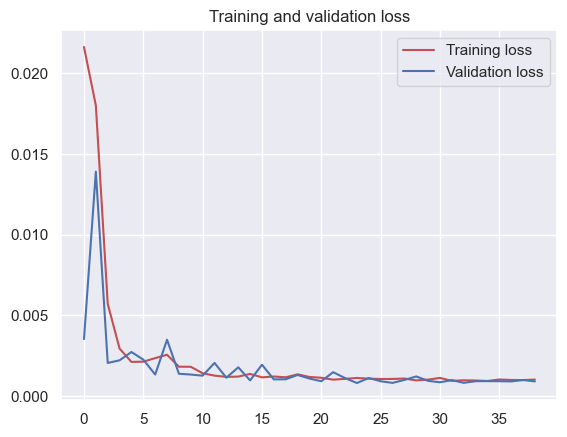

<Figure size 640x480 with 0 Axes>

In [89]:
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(loss))

plt.plot(epochs, loss, 'r', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend(loc=0)
plt.figure()


plt.show()

In [90]:
current_date = pd.to_datetime(df['Open time']).dt.tz_localize(None).max()
target_date = pd.Timestamp('2026-06-09')

if current_date < target_date:
    future_dates = pd.date_range(current_date + pd.Timedelta(days=1), target_date)
    df_extended = pd.concat([df, pd.DataFrame({'Open time': future_dates})], ignore_index=True)
else:
    df_extended = df.copy()

df_extended = df_extended.ffill().bfill()

df_extended['RSI'] = ta.momentum.RSIIndicator(df_extended['Close'], 14).rsi()

macd = ta.trend.MACD(df_extended['Close'])
df_extended['MACD'], df_extended['MACD_Signal'] = macd.macd(), macd.macd_signal()

bb = ta.volatility.BollingerBands(df_extended['Close'], 20, 2)
df_extended['BB_Middle'] = bb.bollinger_mavg()
df_extended['BB_Upper'] = bb.bollinger_hband()
df_extended['BB_Lower'] = bb.bollinger_lband()
df_extended['BB_Width'] = bb.bollinger_wband()

df_extended = df_extended.dropna().reset_index(drop=True)


print("Current date:", current_date)
print("Target date:", target_date)
print("Shape:", df_for_prediction.shape)
print(df_for_prediction.tail())

Current date: 2026-08-20 00:00:00
Target date: 2026-06-09 00:00:00
Shape: (3120, 17)
          Open      High       Low       Volume        RSI         MACD  \
3115  63086.01  63390.00  62716.00   4737.23135  41.953029  -245.518292   
3116  62900.00  64610.01  62751.10  14255.64713  54.280978  -154.392920   
3117  64532.11  65058.81  64027.85  11789.91312  55.486885   -65.817397   
3118  64725.42  70000.00  64166.00  29054.29976  73.461087   372.028468   
3119  69334.78  73400.00  68902.22  35904.79287  80.314652  1005.218152   

      MACD_Signal   BB_Middle      BB_Upper      BB_Lower   BB_Width  \
3115   -82.594770  63846.7015  65259.703232  62433.699768   4.426233   
3116   -96.954400  63877.5565  65321.781917  62433.331083   4.521856   
3117   -90.726999  63914.6135  65405.180738  62424.046262   4.664245   
3118     1.824094  64142.3520  66924.474997  61360.229003   8.674839   
3119   202.502906  64649.2155  69358.636484  59939.794516  14.569151   

      Daily_Return        ROC  

In [91]:
# --- Prediction for 21 August, 2026 (Standalone LSTM) ---

# 1. Scale the `df_for_prediction` using the already fitted scaler_X
scaled_data_for_prediction = scaler_X.transform(df_for_prediction.values)

# 2. Get the very last `n_steps_in` days from this newly scaled dataset
last_n_days = scaled_data_for_prediction[-n_steps_in:]

# Reshape it to (1, n_steps_in, n_features) to match the expected input shape for the LSTM model
last_n_days_reshaped = np.expand_dims(last_n_days, axis=0)

# Standalone LSTM Model Prediction for June 9th
predicted_scaled_price_lstm_solo = lstm_model.predict(last_n_days_reshaped, verbose=0)
predicted_price_june_9_lstm_solo = scaler_y.inverse_transform(predicted_scaled_price_lstm_solo.reshape(-1, 1))

print("==================================================")
print(f"STANDALONE LSTM MODEL PREDICTION FOR August 21, 2026: ${predicted_price_june_9_lstm_solo[0][0]:.2f}")
print("==================================================\n")

# --- Calculate MAPE on the Test Set for Standalone LSTM Model ---
print('Evaluating Standalone LSTM Model on Test Set for MAPE:')

# Ensure y_actual is correctly inverse transformed from y_test
y_actual = scaler_y.inverse_transform(y_test)

# Standalone LSTM Model MAPE
y_pred_scaled_lstm_test = lstm_model.predict(X_test, verbose=0)
y_pred_lstm_test = scaler_y.inverse_transform(y_pred_scaled_lstm_test.reshape(-1, 1))
mape_lstm = mean_absolute_percentage_error(y_actual, y_pred_lstm_test) * 100
print(f"Standalone LSTM Test MAPE: {mape_lstm:.4f}%")

STANDALONE LSTM MODEL PREDICTION FOR August 21, 2026: $66003.45

Evaluating Standalone LSTM Model on Test Set for MAPE:
Standalone LSTM Test MAPE: 3.9872%


# HYBRID MODEL PERFORMANCE ON THE TEST SET

In [92]:
# Create a sub-model that outputs the hidden state of the LSTM layer
feature_extractor = Model(inputs=lstm_model.input, outputs=lstm_model.layers[1].output)

# Extract the temporal features for both train and test sets
z_train = feature_extractor.predict(X_train)
z_test = feature_extractor.predict(X_test)

print(f"Extracted LSTM feature shape: {z_train.shape}")

# Train the XGBoost Regressor on the extracted features
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=10,
    objective='reg:squarederror',
    random_state=42
)

xgb_model.fit(z_train, y_train.ravel())

78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Extracted LSTM feature shape: (2466, 128)


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [93]:
## Analysis of model

In [94]:
n = 30

y_actual = scaler_y.inverse_transform(y_test[-n:])
y_pred = scaler_y.inverse_transform(
    xgb_model.predict(z_test[-n:]).reshape(-1, 1)
)

print(f"MAPE: {mean_absolute_percentage_error(y_actual, y_pred)*100:.4f}%")
print(f"RMSE: {np.sqrt(mean_squared_error(y_actual, y_pred)):.2f}")
print(f"R²: {r2_score(y_actual, y_pred):.4f}")

MAPE: 9.5802%
RMSE: 6375.73
R²: -9.2564


# Features Combinations Maker Function 

In [ ]:
# Adiing feature

df['Volatility'] = df['Close'].pct_change().rolling(14).std()

df['Volume_Change'] = df['Volume'].pct_change()

In [ ]:
# load tyhe dxy data 
df = pd.read_csv("bitcoin_dxy_merged.csv")
df['Date'] = pd.to_datetime(df['Date'])

In [ ]:
# Add DXY
features_dxy = features + ['DXY']
print(len(features_dxy), features_dxy)

In [ ]:
print(df.shape)
print(df[['Date', 'Close', 'DXY']].head())
print(df['DXY'].isna().sum())

# This function test ecah combination of the features and it will give the best 10 results 

In [95]:
from itertools import combinations
import pandas as pd, numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import xgboost as xgb

def test_feature_combinations(df, base_features, candidates, max_comb=4):
    results = []

    # Try 1,2,3... feature combinations
    for r in range(1, max_comb + 1):
        for combo in combinations(candidates, r):

            # Add new features to base features
            cols = base_features + list(combo)
            d = df[cols + ['Close']].dropna().copy()
            X, y = d[cols].values, d[['Close']].values

            # Train/test split
            split = int(len(X) * 0.8)

            # Scale using training data only
            sx, sy = MinMaxScaler(), MinMaxScaler()
            sx.fit(X[:split]); sy.fit(y[:split])
            Xs, ys = sx.transform(X), sy.transform(y)

            # Create sequences
            Xtr, ytr = create_sequences(Xs[:split], ys[:split], n_steps_in)
            Xte, yte = create_sequences(
                Xs[split-n_steps_in:], ys[split-n_steps_in:], n_steps_in
            )

            # Build LSTM
            inp = Input(shape=(n_steps_in, len(cols)))
            lstm = LSTM(128, activation='relu')(inp)
            dense = Dense(64, activation='relu')(lstm)
            drop = Dropout(0.2)(dense)
            out = Dense(1)(drop)

            model = Model(inp, out)
            model.compile(
                optimizer=Adam(learning_rate=0.0005),
                loss='mse'
            )

            # Train LSTM
            model.fit(
                Xtr, ytr, epochs=30, batch_size=64,
                validation_split=0.2, shuffle=False, verbose=0
            )

            # Extract LSTM features
            extractor = Model(model.input, model.layers[1].output)
            ztr = extractor.predict(Xtr, verbose=0)
            zte = extractor.predict(Xte, verbose=0)

            # Train XGBoost
            xgb_model = xgb.XGBRegressor(
                n_estimators=100, learning_rate=0.05,
                max_depth=10,
                objective='reg:squarederror',
                random_state=42
            )
            xgb_model.fit(ztr, ytr.ravel())

            # Predict and inverse scale
            pred = sy.inverse_transform(
                xgb_model.predict(zte).reshape(-1, 1)
            )
            actual = sy.inverse_transform(yte)

            # Store metrics
            results.append({
                'Added Features': ' + '.join(combo),
                'Total Features': len(cols),
                'MAPE': mean_absolute_percentage_error(actual, pred) * 100,
                'RMSE': np.sqrt(mean_squared_error(actual, pred)),
                'R²': r2_score(actual, pred)
            })

            print(f"Done {len(results)}: {' + '.join(combo)}")

    # Best MAPE first
    return pd.DataFrame(results).sort_values('MAPE').reset_index(drop=True)

In [96]:
candidates = ['DXY', 'VIX', 'SP500', 'Gold']

results = test_feature_combinations(
    df, features, candidates, max_comb=4
)

display(results.head(10))

Done 1: DXY
Done 2: VIX


ValueError: Input 0 with name 'input_layer_4' of layer 'functional_8' is incompatible with the layer: expected shape=(None, 30, 18), found shape=(None, 30, 20)

In a Jupyter environment, please rerun this cell to show the HTML representation or trust the notebook.
On GitHub, the HTML representation is unable to render, please try loading this page with nbviewer.org.

In [ ]:
import optuna
from tensorflow.keras.backend import clear_session

def objective(trial):
    clear_session()
    tf.keras.utils.set_random_seed(42)

    inp = Input(shape=(n_steps_in, n_features))

    x = LSTM(
        trial.suggest_int("lstm_units", 32, 256, step=32),
        activation="relu"
    )(inp)

    x = Dense(
        trial.suggest_int("dense_units", 16, 128, step=16),
        activation="relu"
    )(x)

    x = Dropout(
        trial.suggest_float("dropout", 0.1, 0.4, step=0.1)
    )(x)

    out = Dense(1)(x)

    model = Model(inp, out)

    model.compile(
        optimizer=Adam(
            trial.suggest_float("lr", 1e-4, 5e-3, log=True)
        ),
        loss="mse"
    )

    model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=64,
        validation_split=0.2,
        shuffle=False,
        verbose=0,
        callbacks=[EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        )]
    )

    extractor = Model(model.input, model.layers[1].output)

    z_train = extractor.predict(X_train, verbose=0)
    z_test = extractor.predict(X_test, verbose=0)

    xgb_model = xgb.XGBRegressor(
        n_estimators=trial.suggest_int("n_estimators", 50, 200, step=50),
        max_depth=trial.suggest_int("max_depth", 3, 15, step=3),
        learning_rate=trial.suggest_float(
            "xgb_lr", 0.01, 0.3, log=True
        ),
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )

    xgb_model.fit(z_train, y_train.ravel())

    pred = scaler_y.inverse_transform(
        xgb_model.predict(z_test[-60:]).reshape(-1, 1)
    )

    actual = scaler_y.inverse_transform(y_test[-60:])

    return mean_absolute_percentage_error(actual, pred) * 100

In [ ]:
study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42)
)

study.optimize(objective, n_trials=20)

print("Best MAPE:", study.best_value)
print("Best Parameters:", study.best_params)

In [ ]:
# Prepare last 30 days for prediction
df_for_prediction = df[features].tail(n_steps_in)

scaled_data = scaler_X.transform(df_for_prediction)

X_pred = scaled_data.reshape(1, n_steps_in, len(features))

# LSTM feature extraction
extracted_features = feature_extractor.predict(X_pred, verbose=0)

# XGBoost prediction
pred_scaled = xgb_model.predict(extracted_features)

# Convert back to USD
pred_price = scaler_y.inverse_transform(
    pred_scaled.reshape(-1, 1)
)[0, 0]

print("=" * 50)
print(f"Predicted Bitcoin Price: ${pred_price:,.2f}")
print("=" * 50)

# RESULTS AND COMPARISION

## Actual vs Predicted Price

In [ ]:
y_actual = scaler_y.inverse_transform(y_test).flatten()

y_pred_scaled = xgb_model.predict(z_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

plt.figure(figsize=(14, 6))
plt.plot(y_actual, label='Actual Price')
plt.plot(y_pred, label='Predicted Price')
plt.title('Actual vs Predicted Bitcoin Price')
plt.xlabel('Test Samples')
plt.ylabel('Bitcoin Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

## Training vs Validation Loss

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## Prediction Error / Residual Plot

In [ ]:
residuals = y_actual - y_pred

plt.figure(figsize=(14, 6))
plt.plot(residuals)
plt.axhline(0, linestyle='--')
plt.title('Prediction Residuals')
plt.xlabel('Test Samples')
plt.ylabel('Actual - Predicted Price')
plt.grid(True)
plt.show()

## Actual vs Predicted Scatter Plot

In [ ]:
plt.figure(figsize=(14, 6))
plt.scatter(y_actual, y_pred, alpha=0.5)
plt.plot([y_actual.min(), y_actual.max()],
         [y_actual.min(), y_actual.max()],
         linestyle='--')
plt.title('Actual vs Predicted Bitcoin Price')
plt.xlabel('Actual Price (USD)')
plt.ylabel('Predicted Price (USD)')
plt.grid(True)
plt.show()

## Final Prediction — AUGUST 21

In [ ]:
scaled = scaler_X.transform(df_for_prediction[features])
last_days = scaled[-n_steps_in:]
X_pred = np.expand_dims(last_days, axis=0)

features_pred = feature_extractor.predict(X_pred, verbose=0)
pred_scaled = xgb_model.predict(features_pred)

pred_price = scaler_y.inverse_transform(
    pred_scaled.reshape(-1, 1)
)[0, 0]

print(f"Predicted Bitcoin Price for 22 August 2026: ${pred_price:,.2f}")

In [ ]:
n = 60

actual_30 = y_actual[-n:]
pred_30 = y_pred_hybrid_test[-n:]

mape_30 = mean_absolute_percentage_error(actual_60, pred_60) * 100
rmse_30 = np.sqrt(np.mean((actual_60 - pred_60)**2))
r2_30 = r2_score(actual_60, pred_60)

print(f"Last 60 Days MAPE : {mape_60:.2f}%")
print(f"Last 60 Days RMSE : ${rmse_60:.2f}")
print(f"Last 60 Days R²   : {r2_60:.4f}")

In [ ]:
n = 60

y_actual = scaler_y.inverse_transform(y_test[-n:])

y_pred = scaler_y.inverse_transform(
    xgb_model.predict(z_test[-n:]).reshape(-1, 1)
)

print(
    f"MAPE: "
    f"{mean_absolute_percentage_error(y_actual, y_pred)*100:.4f}%"
)

print(
    f"RMSE: "
    f"{np.sqrt(mean_squared_error(y_actual, y_pred)):.2f}"
)

print(
    f"R²: "
    f"{r2_score(y_actual, y_pred):.4f}"
)

In [ ]:
print("Last 30 predictions:")
print(y_pred_scaled_hybrid_test[-30:])

print("\nPrevious 30 predictions:")
print(y_pred_scaled_hybrid_test[-60:-30])